### Building ML Habbits

In [71]:
import pandas as pd
from matplotlib import pyplot as plt
from xgboost import XGBClassifier, XGBRegressor

import utilities as ut
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
import xgboost as xgb
from theme import set_theme
set_theme("dark")

{'rc_params': {'figure.facecolor': '#1a1a19',
  'axes.facecolor': '#1a1a19',
  'savefig.facecolor': '#1a1a19',
  'axes.edgecolor': '#898781',
  'axes.labelcolor': '#c3c2b7',
  'axes.titlecolor': '#ffffff',
  'axes.titlelocation': 'left',
  'axes.titlesize': 11,
  'axes.titleweight': 'bold',
  'axes.spines.top': False,
  'axes.spines.right': False,
  'text.color': '#ffffff',
  'xtick.color': '#c3c2b7',
  'ytick.color': '#c3c2b7',
  'axes.grid': True,
  'axes.grid.axis': 'y',
  'grid.color': '#383835',
  'grid.linewidth': 0.8,
  'grid.linestyle': '-',
  'lines.linewidth': 1.8,
  'legend.frameon': False,
  'font.size': 9.5,
  'text.parse_math': False},
 'palette': ['#3987e5',
  '#d95926',
  '#199e70',
  '#c98500',
  '#d55181',
  '#008300',
  '#9085e9',
  '#e66767'],
 'colors': {'surface': '#1a1a19',
  'ink': '#ffffff',
  'ink_secondary': '#c3c2b7',
  'muted': '#898781',
  'grid': '#383835',
  'neutral': '#383835',
  'palette': ['#3987e5',
   '#d95926',
   '#199e70',
   '#c98500',
   '#d55

In [2]:
# import data
path = r"C:\Users\Amin\PycharmProjects\Asia Ags\data\processed\feature_df_processed.parquet"

df = pd.read_parquet(path)
spread = df[["c_yw_spread"]].copy()
spread["yw_spread_chg"] = spread["c_yw_spread"] - spread["c_yw_spread"].shift(1)
spread = spread.dropna()
ts = spread.copy()

# assess data
ts.describe()
print("Mean:", ts["yw_spread_chg"].mean())
print("Skewness:", ts["yw_spread_chg"].skew())
print("Variance:", ts["yw_spread_chg"].var())
print("Kurtosis:", ts["yw_spread_chg"].kurt())

Mean: 0.13025848960973138
Skewness: 0.1501687189899998
Variance: 811.4962552943829
Kurtosis: 13.416249350054041


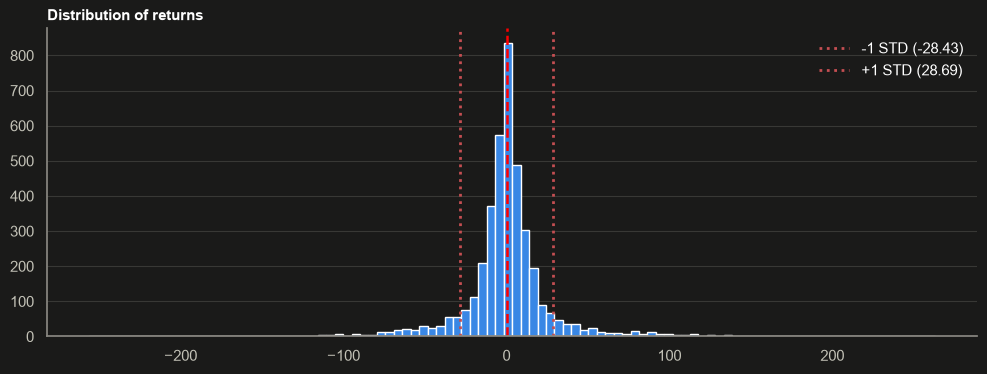

In [72]:
import seaborn as sns
mean = ts["yw_spread_chg"].mean()
std = ts["yw_spread_chg"].std()
fig, ax = plt.subplots(figsize=(12,4))
ax.hist(ts["yw_spread_chg"], bins=100)
plt.axvline(x=mean, color="red", linestyle="--")
# 5. Plot ±1 Standard Deviation Lines
plt.axvline(mean - std, color="r", linestyle=":", linewidth=2, label=f"-1 STD ({mean-std:.2f})")
plt.axvline(mean + std, color="r", linestyle=":", linewidth=2, label=f"+1 STD ({mean+std:.2f})")
plt.legend(loc="upper right")
plt.title("Distribution of returns")

plt.show()

In [4]:
# check for stationarity
print("Spread Chg:", ut.quick_adf(ts["yw_spread_chg"]))
print("Raw series", ut.quick_adf(ts["c_yw_spread"]))

# Is the series mean reverting
ols = ut.ols_model(ts, "c_yw_spread", 10)
print(ols.summary())

Spread Chg: {'stat': -11.526332662732061, 'pvalue': 3.9279823148333596e-21, 'n_lags': 23, 'stationary_5pct': True}
Raw series {'stat': -2.7133560124332172, 'pvalue': 0.07175547385276312, 'n_lags': 24, 'stationary_5pct': False}
                            AutoReg Model Results                             
Dep. Variable:            c_yw_spread   No. Observations:                 3936
Model:                    AutoReg(10)   Log Likelihood              -18731.332
Method:               Conditional MLE   S.D. of innovations             28.220
Date:                Wed, 07 Oct 2026   AIC                          37486.665
Time:                        14:06:02   BIC                          37562.000
Sample:                            10   HQIC                         37513.391
                                 3946                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

C:\Users\Amin\PycharmProjects\Asia Ags\src\utilities.py:294: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, n_lags, *_ = adfuller(clean, autolag="AIC")
C:\Users\Amin\PycharmProjects\Asia Ags\src\utilities.py:294: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, n_lags, *_ = adfuller(clean, autolag="AIC")
C:\Users\Amin\PycharmProjects\Asia Ags\.venv

In [5]:
# What is the spreads sharpe
ut.calculate_sharpe(ts, "yw_spread_chg")

{'sharpe': 0.07258770213572585,
 'mean_period': 0.13025848960973138,
 'std_period': 28.486773339470773,
 'ann_return': 32.825139381652306,
 'ann_vol': np.float64(452.21350746542777),
 'n': 3946}

In [6]:
# build features (rebuilt from the clean spread, so re-running this cell never loses rows)
# Every feature is shifted by 1: known at the close of t-1. The target is the change on day t,
# yw_spread_chg itself - no further shift, or the model would be predicting two days ahead.
ts = spread.copy()
ts["feat_lag1"] = ts["yw_spread_chg"].shift(1)
ts["feat_lag2"] = ts["yw_spread_chg"].shift(2)
# Given Ljungbox - add lag 6
ts["feat_lag6"] = ts["yw_spread_chg"].shift(6)
# 2. Capture the Volatility Clustering (from the 'squared' results)
# A rolling 5-day absolute deviation tells the model if the market is currently volatile
ts["feat_rolling_vol_5"] = ts["yw_spread_chg"].shift(1).rolling(window=5).std()
ts["feat_rolling_vol_20"] = ts["yw_spread_chg"].shift(1).rolling(window=20).std()

# 3. Capture Trend Momentum
ts["feat_rolling_mean_5"] = ts["yw_spread_chg"].shift(1).rolling(window=5).mean()
ts["feat_rolling_mean_10"] = ts["yw_spread_chg"].shift(1).rolling(window=10).mean()
ts["feat_rolling_mean_20"] = ts["yw_spread_chg"].shift(1).rolling(window=20).mean()

feature_cols = [c for c in ts.columns if c.startswith("feat_")]
ts = ts.dropna(subset=feature_cols + ["yw_spread_chg"])

                            ic   p_value       n
feat_lag1             0.074801  0.000003  3926.0
feat_rolling_mean_5   0.027503  0.084874  3926.0
feat_rolling_mean_10  0.014870  0.351613  3926.0
feat_rolling_mean_20  0.006857  0.667554  3926.0
feat_lag6            -0.007414  0.642378  3926.0
feat_rolling_vol_5   -0.017759  0.265947  3926.0
feat_lag2            -0.021542  0.177181  3926.0
feat_rolling_vol_20  -0.025916  0.104462  3926.0


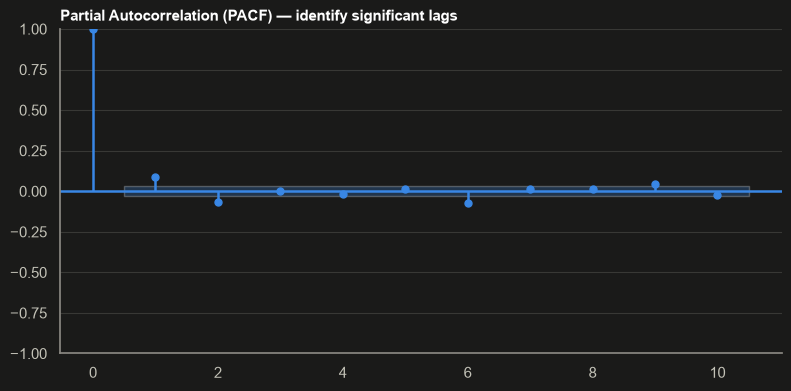

None
{'n': 3926, 'lags':       lb_stat     lb_pvalue
1   28.261123  1.060037e-07
2   40.886101  1.323415e-09
3   41.333212  5.557079e-09
4   42.020228  1.652135e-08
5   42.643278  4.364204e-08
6   60.755489  3.160586e-11
7   60.775744  1.056520e-10
8   63.382048  1.007256e-10
9   72.166232  5.717307e-12
10  73.104577  1.111190e-11, 'squared':         lb_stat      lb_pvalue
1    972.290164  1.894393e-213
2   1300.777707  3.465052e-283
3   1472.779016   0.000000e+00
4   1659.818442   0.000000e+00
5   1868.499553   0.000000e+00
6   2023.110687   0.000000e+00
7   2148.959529   0.000000e+00
8   2280.754042   0.000000e+00
9   2385.684214   0.000000e+00
10  2550.942543   0.000000e+00, 'white_noise_5pct': False, 'acf': array([ 8.48112870e-02, -5.66785744e-02, -1.06648861e-02, -1.32183211e-02,
        1.25863204e-02, -6.78528168e-02, -2.26877142e-03,  2.57326122e-02,
        4.72352935e-02, -1.54362473e-02, -2.06198790e-03,  4.94162861e-02,
        2.80267563e-02, -5.62501988e-02,  2.14763014e-

In [73]:
# is there ic between feat and target
print(ut.ic_rank_spearman(ts, feature_cols, "yw_spread_chg").sort_values(by="ic", ascending=False))

# feat correlation
#print("Feat corr:", ut.feature_correlation(ts, ["feat_lag1", "feat_lag2", "feat_lag6", "feat_rolling_vol_5", "feat_rolling_vol_5","feat_rolling_mean_5", "yw_spread_chg"], "spearman"))
# Any Autocorrelation present
print(ut.pacf_plot(ts, ["yw_spread_chg"], 10))

# Ljungbox test for linear autocorrelation
print(ut.ljung_box(ts["yw_spread_chg"], 10))

In [69]:
# newey west t stats
ut.nw_t_stat(ts, ["feat_lag1", "feat_lag2", "feat_lag6", "feat_rolling_vol_5", "feat_rolling_vol_20","feat_rolling_mean_5", "feat_rolling_mean_10", "feat_rolling_mean_20"], "yw_spread_chg", 10)

,t_nw,p_nw,n
feat_lag1,4.191267,0.000028,3926.0
feat_lag2,-1.319268,0.187080,3926.0
feat_lag6,-0.385836,0.699618,3926.0
feat_rolling_vol_5,-1.015067,0.310074,3926.0
feat_rolling_vol_20,-1.421771,0.155093,3926.0
feat_rolling_mean_5,1.478951,0.139153,3926.0
feat_rolling_mean_10,0.807811,0.419200,3926.0
feat_rolling_mean_20,0.348549,0.727428,3926.0


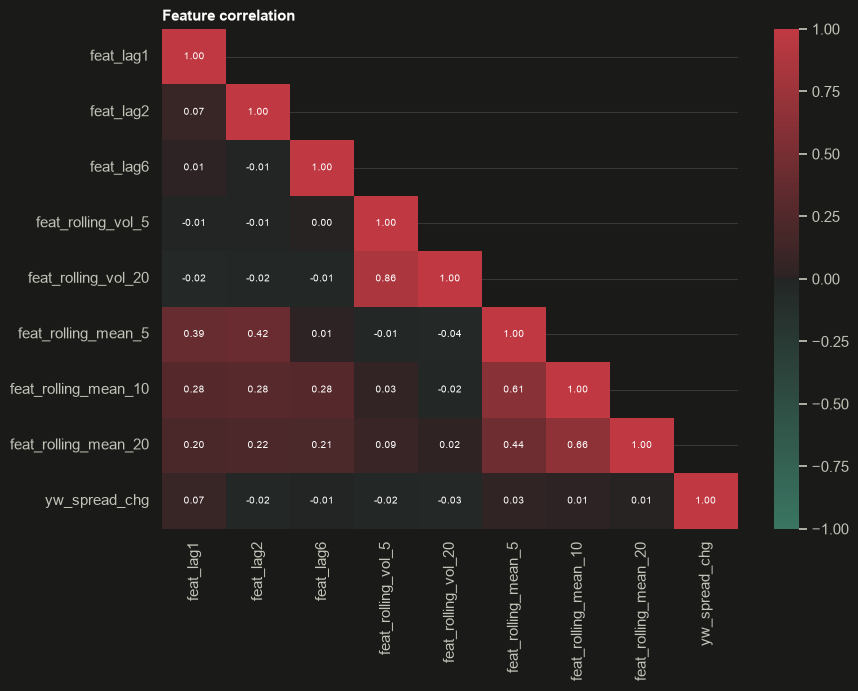

,feat_lag1,feat_lag2,feat_lag6,feat_rolling_vol_5,feat_rolling_vol_20,feat_rolling_mean_5,feat_rolling_mean_10,feat_rolling_mean_20,yw_spread_chg
feat_lag1,1.000000,0.074438,0.009948,-0.005130,-0.024354,0.390933,0.276528,0.199638,0.074801
feat_lag2,0.074438,1.000000,-0.005436,-0.007082,-0.021104,0.417251,0.284966,0.215403,-0.021542
feat_lag6,0.009948,-0.005436,1.000000,0.004871,-0.012424,0.007837,0.278028,0.205352,-0.007414
feat_rolling_vol_5,-0.005130,-0.007082,0.004871,1.000000,0.856966,-0.011297,0.033953,0.085934,-0.017759
feat_rolling_vol_20,-0.024354,-0.021104,-0.012424,0.856966,1.000000,-0.038338,-0.020867,0.020679,-0.025916
feat_rolling_mean_5,0.390933,0.417251,0.007837,-0.011297,-0.038338,1.000000,0.612473,0.441062,0.027503
feat_rolling_mean_10,0.276528,0.284966,0.278028,0.033953,-0.020867,0.612473,1.000000,0.657542,0.014870
feat_rolling_mean_20,0.199638,0.215403,0.205352,0.085934,0.020679,0.441062,0.657542,1.000000,0.006857
yw_spread_chg,0.074801,-0.021542,-0.007414,-0.017759,-0.025916,0.027503,0.014870,0.006857,1.000000


In [74]:
# view ic heatmap
ut.plot_feature_correlation(ts, ["feat_lag1", "feat_lag2", "feat_lag6", "feat_rolling_vol_5", "feat_rolling_vol_20","feat_rolling_mean_5", "feat_rolling_mean_10", "feat_rolling_mean_20", "yw_spread_chg"], "spearman")

### Linear Regression Model: 1 Feature

In [60]:
from sklearn.linear_model import HuberRegressor

# Model 1: Linear Regression
X = ts[["feat_lag1"]]
y = ts["yw_spread_chg"]
# set up walk forward
tscv = TimeSeriesSplit(n_splits=5)

# blank df to hold OOS
ts["predictions"] = np.nan
# Fold scores list
fold_coefs = []
fold_intercepts = []
fold_scores = []

# Walk forward loop
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Fit model
    model = HuberRegressor()  ## LinearRegression
    model.fit(X_train, y_train)

    # Capture params
    fold_coefs.append(model.coef_)
    fold_intercepts.append(model.intercept_)

    # Predict on the unseen
    y_hat = model.predict(X_test)
    score = root_mean_squared_error(y_test, y_hat)
    fold_scores.append(score)

    # map predictions to df
    ts.iloc[test_idx, ts.columns.get_loc("predictions")] = y_hat

    # results
    #print(f"Fold {fold +1} - Score: {score}")
    print(f"Fold {fold + 1} - Score: {score:.4f} | Coef: {model.coef_[0]:.4f}")


#Overall scores
print(f"Mean Score: {np.mean(fold_scores)}, Std: {np.std(fold_scores)}")

Fold 1 - Score: 20.0766 | Coef: -0.0187
Fold 2 - Score: 34.2722 | Coef: 0.1115
Fold 3 - Score: 22.3433 | Coef: 0.1393
Fold 4 - Score: 19.2766 | Coef: 0.1002
Fold 5 - Score: 48.3575 | Coef: 0.0750
Mean Score: 28.865227718454314, Std: 11.143637322962368



--- Walk Forward Results
Overall R2: 0.0047
Total points Generated: 4135.0
Out of Sample win Rate: 48.44%
Sharpe Ratio: {'sharpe': 0.6476836140440223, 'mean_period': 1.264525993883792, 'std_period': 30.993107439947366, 'ann_return': 318.6605504587156, 'ann_vol': np.float64(492.0003278592388), 'n': 3270}


<Axes: title={'left': 'Time Series Strategy Return - Yellow/White Spread'}, xlabel='dt'>

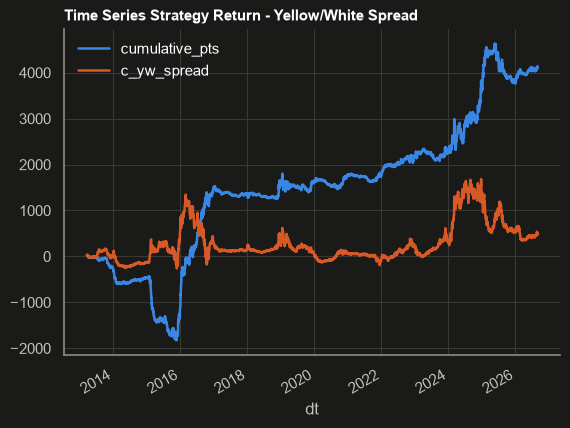

In [75]:
# Look at signals
df_eval = ts.dropna(subset=["predictions"]).copy()
df_eval["signal"] = np.sign(df_eval["predictions"])
df_eval["huber_strat_return"] = df_eval["signal"] * df_eval["yw_spread_chg"]
df_eval["cumulative_pts"] = df_eval["huber_strat_return"].cumsum()

# Metrics
win_rate = (df_eval["huber_strat_return"] >0).mean()
overall_r2 = r2_score(df_eval["yw_spread_chg"], df_eval["predictions"])
print(f"\n--- Walk Forward Results")
print(f"Overall R2: {overall_r2:.4f}")
print(f"Total points Generated: {df_eval["cumulative_pts"].iloc[-1]}")
print(f"Out of Sample win Rate: {(win_rate * 100).round(2)}%")
print(f"Sharpe Ratio: {ut.calculate_sharpe(df_eval, "huber_strat_return")}")
df_eval[["cumulative_pts", "c_yw_spread"]].plot(title="Time Series Strategy Return - Yellow/White Spread")

### Baseline test: Apply the signal with only the sign of lag1 - Does it improve over the ML model?


--- Walk Forward Results
Total points Generated: 7078.0
Out of Sample win Rate: 46.7%
Sharpe Ratio: {'sharpe': 1.1404964658773582, 'mean_period': 2.164525993883792, 'std_period': 30.127918801112283, 'ann_return': 545.4605504587156, 'ann_vol': np.float64(478.26588400614213), 'n': 3270}


<Axes: title={'left': 'Time Series Strategy Return - Yellow/White Spread'}, xlabel='dt'>

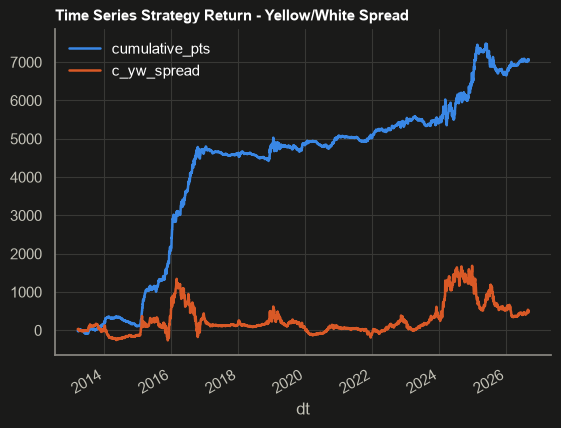

In [76]:
# baseline test with no ML
df_eval = ts.dropna(subset=["predictions"]).copy()
df_eval["signal_test"] = np.sign(df_eval["feat_lag1"])
df_eval["return"] = df_eval["signal_test"] * df_eval["yw_spread_chg"]
df_eval["cumulative_pts"] = df_eval["return"].cumsum()

# Metrics
win_rate = (df_eval["return"] >0).mean()
print(f"\n--- Walk Forward Results")
print(f"Total points Generated: {df_eval["cumulative_pts"].iloc[-1]}")
print(f"Out of Sample win Rate: {(win_rate * 100).round(2)}%")
print(f"Sharpe Ratio: {ut.calculate_sharpe(df_eval, "return")}")
df_eval[["cumulative_pts", "c_yw_spread"]].plot(title="Time Series Strategy Return - Yellow/White Spread")

### XGBoost Regressor Model: tested on the same features as linear baseline

In [53]:
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr
# prepare data
xgb_df = ts.copy()
xgb_df.drop(columns=["predictions"], inplace=True)

X_gb = xgb_df[["feat_lag1"]]
y_gb = xgb_df["yw_spread_chg"]

# Model
model_xgb = XGBRegressor()

# predic
xgb_df["predictions"] = np.nan

# build walk forward and grid search
# Setup cross validation
tscv_xgb = TimeSeriesSplit(n_splits=5)
# param grid
params_grid = {
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [25, 50, 100]
}
# track fold scores
fold_scores_xgb = []

# build own ic score for grid search
def ic_score(y_true, y_pred):
    if np.std(y_pred) == 0:
        return 0.0
    return spearmanr(y_true, y_pred).correlation
    # build
ic_scorer = make_scorer(ic_score, greater_is_better=True)

# loop through outer walk forward
for fold, (train_idx, test_idx) in enumerate(tscv_xgb.split(X_gb)):
    X_train, X_test = X_gb.iloc[train_idx], X_gb.iloc[test_idx]
    y_train, y_test = y_gb.iloc[train_idx], y_gb.iloc[test_idx]


    # Inner loop look for grid search
    gscv = GridSearchCV(
        estimator=model_xgb,
        param_grid=params_grid,
        cv=TimeSeriesSplit(n_splits=3),
        scoring=ic_scorer)
    # fit
    gscv.fit(X_train, y_train)

    # Extract best model
    best_model = gscv.best_estimator_
    print(f"Fold {fold + 1} Best Params: {gscv.best_params_}")

    # OOS test
    y_hat_gb = best_model.predict(X_test)
    score = root_mean_squared_error(y_test, y_hat_gb)
    fold_scores_xgb.append(score)

    # map predictions to df
    xgb_df.iloc[test_idx, xgb_df.columns.get_loc("predictions")] = y_hat_gb
    print(f"{fold + 1} - Score: {score:.4f}")

print(f"Overall Average OOS RMSE: {np.mean(fold_scores_xgb)}")
print(f"OOS IC:", spearmanr(y_test, y_hat_gb).correlation)

Fold 1 Best Params: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 50}
1 - Score: 20.1024
Fold 2 Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
2 - Score: 34.2494
Fold 3 Best Params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 25}
3 - Score: 22.1937
Fold 4 Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
4 - Score: 19.2332
Fold 5 Best Params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 25}
5 - Score: 48.1561
Overall Average OOS RMSE: 28.786965643977105


In [70]:
# cv results
cv_results = pd.DataFrame(gscv.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score")
cv_results.head()

,params,mean_test_score,std_test_score,rank_test_score
3,"{'learning_rate': 0.01, 'max_depth': 4, 'n_est...",0.008570,0.026415,1
26,"{'learning_rate': 0.05, 'max_depth': 6, 'n_est...",0.004697,0.027943,2
39,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.002195,0.029254,3
35,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.002026,0.028307,4
40,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",-0.000432,0.024694,5



--- Walk Forward Results
Total points Generated: 4177.0
Out of Sample win Rate: 48.38%
Sharpe Ratio: {'sharpe': 0.6542733849091079, 'mean_period': 1.2773700305810398, 'std_period': 30.992580573277323, 'ann_return': 321.89724770642204, 'ann_vol': np.float64(491.99196411014066), 'n': 3270}


<Axes: title={'left': 'Time Series Strategy Return - Yellow/White Spread'}, xlabel='dt'>

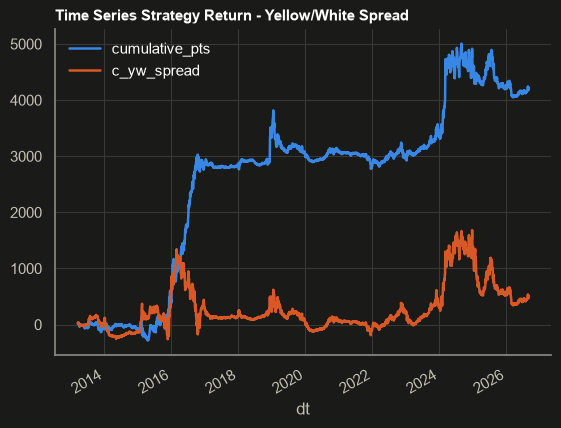

In [77]:
# XGBoost Results
xgb_eval = xgb_df.dropna(subset=["predictions"]).copy()
xgb_eval["signal"] = np.sign(xgb_eval["predictions"])
xgb_eval["xgb_return"] = xgb_eval["signal"] * xgb_eval["yw_spread_chg"]
xgb_eval["cumulative_pts"] = xgb_eval["xgb_return"].cumsum()

# Metrics
win_rate = (xgb_eval["xgb_return"] >0).mean()
print(f"\n--- Walk Forward Results")
print(f"Total points Generated: {xgb_eval["cumulative_pts"].iloc[-1]}")
print(f"Out of Sample win Rate: {(win_rate * 100).round(2)}%")
print(f"Sharpe Ratio: {ut.calculate_sharpe(xgb_eval, "xgb_return")}")
eval[["cumulative_pts", "c_yw_spread"]].plot(title="Time Series Strategy Return - Yellow/White Spread")

### Classification: Can a classifier filter trades / Meta Modelling